# SFR Fly Mean-Reversion — 1. Rolling z-score fade

**Formulation: level z-score.** The oldest and most-used desk rule: standardise
the fly against its own trailing distribution and fade the tails.

The traded object is a butterfly of SR3 futures, `fly = 2*belly - front - back`
in bp (the Query layer's `FLY RATE` convention). One package is 1 front + 2
belly + 1 back = **4 contracts** and moves **$25 per bp of fly**; the league
table sizes at 100 packages, so $2,500/bp and 400 contracts.

Standing honesty rules, enforced by the engine rather than by the notebook:
signal at close `t` fills at `t+1`; a deterministic exit (fixed horizon, max
hold, stop, end of sample) is known at entry and is **not** lagged a second
time; the round trip is charged once on the exit bar; gates apply at entry
only. Both signs are always swept — mean reversion is a finding, not an
assumption.

Marks are **raw SR3 settlement prices**, never a fitted curve. That is a
measured decision: `USD-SOFR-1D-Q16STIRT` on 2026-07-27 returned front rates
22–36bp away from the settles it is calibrated to and bit-identical rates
across strip slots 8–14, and its fly correlates **−0.377** with the settle fly
(`notebooks/rv/_probe_curve_vs_settle.py`). `Q12STIRT` reprices the same
settles to 0.5bp. A backtest on the broken curve would have been trading its
own interpolation error.

In [1]:
CONFIG = dict(
    # --- universe -----------------------------------------------------------
    structures=("3m", "6m"),        # 3m fly = slots (i,i+1,i+2); 6m = (i,i+2,i+4)
    primary_structure="3m",
    primary_window="liquid16",      # 2022+: every strip slot trades every session
    long_window="front8",           # 2019+: slots 1-8 only; buys ZIRP + hiking
    # --- costs (bp round trip on the package) -------------------------------
    cost_bp=1.5,                    # 3 legs x 2 sides x 0.25bp
    n_packages=100,                 # $2,500 per bp
    # --- grid ---------------------------------------------------------------
    windows=(40, 60, 120, 250),     # z-score lookback, business days
    mas=(1, 3, 5),                  # smoothing applied before standardising
    entry_zs=(1.0, 1.5, 2.0, 2.5),
    exits=("z0", "half", "t5", "t20"),
    directions=("fade", "momentum"),
    max_hold=20,
    lag=1,
)
CONFIG

{'structures': ('3m', '6m'),
 'primary_structure': '3m',
 'primary_window': 'liquid16',
 'long_window': 'front8',
 'cost_bp': 1.5,
 'n_packages': 100,
 'windows': (40, 60, 120, 250),
 'mas': (1, 3, 5),
 'entry_zs': (1.0, 1.5, 2.0, 2.5),
 'exits': ('z0', 'half', 't5', 't20'),
 'directions': ('fade', 'momentum'),
 'max_hold': 20,
 'lag': 1}

In [2]:
import sys
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

import dataclasses

from RVUtils.MeanRev import MRConfig, grid_search, run_backtest, run_continuous
from RVUtils.MeanRev.signals import bollinger_signal, zscore_signal
from sfr_fly_meanrev_common import (
    coverage_report, grid_block, header_block, league_row, load_lab,
    per_slot_table, regime_block, run_family, shadow_block, sign_test,
    three_panel_equity,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
GRID = {"window": CONFIG["windows"], "ma": CONFIG["mas"],
        "entry_z": CONFIG["entry_zs"], "exit_style": CONFIG["exits"],
        "direction": CONFIG["directions"]}
PARAMS = ["window", "ma", "entry_z", "exit_style", "direction"]
SIG = lambda L, window, ma: zscore_signal(L, window=window, ma=ma)   # noqa: E731

lab = load_lab(CONFIG["primary_structure"], CONFIG["primary_window"])
print(f"{CONFIG['primary_structure']} / {CONFIG['primary_window']}: "
      f"{lab['levels'].shape[1]} absolute flies, {lab['levels'].shape[0]} sessions, "
      f"{lab['levels'].index.min().date()} -> {lab['levels'].index.max().date()}")
print(f"window rationale: {lab['window_why']}")
print(coverage_report(lab).round(2).to_string())

3m / liquid16: 34 absolute flies, 1150 sessions, 2022-01-03 -> 2026-07-29
window rationale: every strip slot trades every session from 2022
                cm_slot    pack  n_obs  n_keys  median_bp  iqr_bp  daily_sd_bp  median_min_oi
cm_label_short                                                                               
SFR123                2  whites   1150      20        5.0   21.19         2.41       966565.5
SFR234                3  whites   1150      20        1.0   16.00         1.49       819949.5
SFR345                4  whites   1150      20       -2.5   11.50         1.11       696963.5
SFR456                5    reds   1150      20       -3.5    7.50         0.95       640434.0
SFR567                6    reds   1150      20       -3.5    5.00         0.80       595859.5
SFR678                7    reds   1150      20       -3.5    5.50         0.60       538729.5
SFR789                8    reds   1149      19       -2.5    3.50         0.57       471601.0
SFR-8-9-10    

## The economics before any backtest

A butterfly's daily standard deviation falls from ~2.4bp at `SFR123` to ~0.4bp
at `SFR-14-15-16`. Against a **1.5bp** round trip, the back of the strip has to
move nearly four daily sigmas just to pay the spread. This table is the single
most important thing in the notebook: it says in advance which slots can
possibly support a mean-reversion program.

In [3]:
cov = coverage_report(lab)
cov["cost_in_daily_sd"] = CONFIG["cost_bp"] / cov["daily_sd_bp"]
cov["iqr_in_cost"] = cov["iqr_bp"] / CONFIG["cost_bp"]
print("round-trip cost expressed in daily sigmas, and IQR expressed in round trips:")
print(cov[["cm_slot", "pack", "daily_sd_bp", "iqr_bp", "cost_in_daily_sd",
           "iqr_in_cost"]].round(2).to_string())

round-trip cost expressed in daily sigmas, and IQR expressed in round trips:
                cm_slot    pack  daily_sd_bp  iqr_bp  cost_in_daily_sd  iqr_in_cost
cm_label_short                                                                     
SFR123                2  whites         2.41   21.19              0.62        14.12
SFR234                3  whites         1.49   16.00              1.00        10.67
SFR345                4  whites         1.11   11.50              1.35         7.67
SFR456                5    reds         0.95    7.50              1.58         5.00
SFR567                6    reds         0.80    5.00              1.87         3.33
SFR678                7    reds         0.60    5.50              2.51         3.67
SFR789                8    reds         0.57    3.50              2.64         2.33
SFR-8-9-10            9  greens         0.53    2.00              2.84         1.33
SFR-9-10-11          10  greens         0.45    1.00              3.35         0.67

## Primary run — 3m flies, 2022+ (every slot liquid)


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/384 configs


  50/384 configs


  75/384 configs


  100/384 configs


...

  300/384 configs


  325/384 configs


  350/384 configs


  375/384 configs


  384 configs | median -693.62bp | IQR [-1009.94, -402.00] | 0% net-positive | best -106.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  ma  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250   5      2.5        t20      fade       141     0.191      -0.752       -106.00      -265000.0  -0.646    -145.75
    250   5      2.5         z0      fade       141     0.199      -0.777       -109.50      -273750.0  -0.670    -140.75
    250   5      2.5       half      fade       141     0.206      -0.798       -112.50      -281250.0  -0.691    -140.75
    250   1      2.5        t20      fade       163     0.209      -0.761       -124.00      -310000.0  -0.683    -162.75
    250   1      2.5         z0      fade       165     0.230      -0.761       -125.50      -313750.0  -0.696    -159.75
    250   1      2.5       half      fade       168     0.214      -0.866       -145.50      -363750.0  

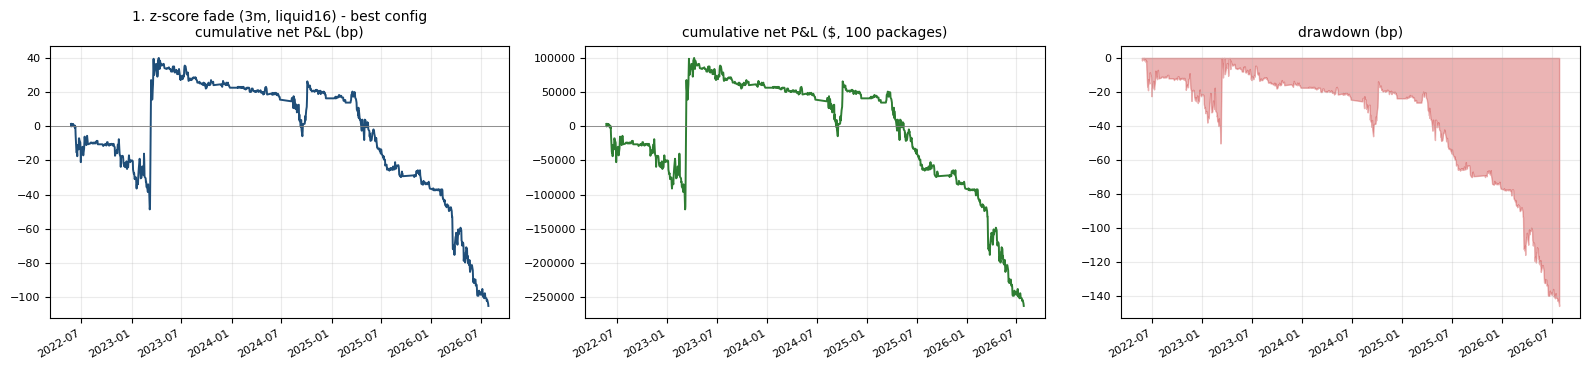


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
U22-Z22-H23   -1  2022-05-20 2022-05-23 2022-06-22    20  2.507      21.5      33.50    -12.00      1.5  -13.50 -33750.0        time
Z22-H23-M23   -1  2022-06-15 2022-06-16 2022-07-18    20  2.653      25.0      11.00     14.00      1.5   12.50  31250.0        time
U22-Z22-H23   -1  2022-06-23 2022-06-24 2022-07-25    20  2.711      30.0      37.00     -7.00      1.5   -8.50 -21250.0        time
Z24-H25-M25    1  2022-06-23 2022-06-24 2022-07-25    20 -2.699      -2.5      -2.00      0.50      1.5   -1.00  -2500.0        time
H25-M25-U25    1  2022-08-01 2022-08-02 2022-08-30    20 -2.568      -3.0      -1.50      1.50      1.5   -0.00     -0.0        time
U25-Z25-H26    1  2022-09-12 2022-09-13 2022-10-11    20 -2.627      -2.0      -1.50      0.50      1.5   -1.00  -2500.0        time
U22-Z22-H23   -1  2022-09-15 2022-09-16 20


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5       141           105.5        -106.0      -0.752     0.191  -0.646     -145.8      19.5          False             False
         belly       1            0.5       141           460.0         389.5       2.762     0.525   0.475     -361.0      19.5           True              True
belly_vs_front       2            1.0       141           -43.0        -184.0      -1.305     0.206  -0.750     -238.8      19.5          False             False
 belly_vs_back       2            1.0       141           148.5           7.5       0.053     0.440   0.054      -66.5      19.5           True              True
  -> SHADOWED - a simpler instrument beats the fly on net bp
1. z-score fade (3m, liquid16) - MEDIAN config (the anti

In [4]:
out = run_family("1. z-score fade (3m, liquid16)", lab=lab, signal_fn=SIG,
                 grid_spec=GRID, params=PARAMS, base=BASE, cls="level",
                 note="rolling z of the fly level; both signs swept")

## Lag ablation — how much of the result is same-bar execution?

Reported as an ablation only. Lag-0 assumes you can trade the close you used
to form the signal; the prior lab measured that inflating gross P&L by 56–72%.

In [5]:
rows = []
for lag in (0, 1, 2):
    cfg = dataclasses.replace(out["config"], lag=lag)
    r = run_backtest(cfg, levels=lab["levels"], signal=out["signal"], gate=lab["gate"])
    rows.append({"lag": lag, **{k: r.metrics[k] for k in
                                ("n_trades", "hit_rate", "avg_net_bp",
                                 "total_net_bp", "sharpe")}})
lag_tbl = pd.DataFrame(rows)
print(lag_tbl.round(3).to_string(index=False))
if len(lag_tbl) > 1 and lag_tbl.loc[1, "total_net_bp"] != 0:
    infl = (lag_tbl.loc[0, "total_net_bp"] - lag_tbl.loc[1, "total_net_bp"])
    print(f"\n  lag-0 minus lag-1 = {infl:+.1f}bp of pure execution assumption")

 lag  n_trades  hit_rate  avg_net_bp  total_net_bp  sharpe
   0       146     0.185      -0.877       -128.00  -1.027
   1       141     0.191      -0.752       -106.00  -0.646
   2       136     0.191      -0.899       -122.25  -0.721

  lag-0 minus lag-1 = -22.0bp of pure execution assumption


## Threshold versus continuous sizing

A threshold rule is in or out; continuous sizing holds `-clip(z, ±2)` packages
and rebalances daily, charging turnover rather than a round trip. If the edge
is real but small, continuous sizing usually harvests more of it — at the cost
of paying the spread far more often.

In [6]:
rows = []
for cap in (1.0, 2.0, 3.0):
    for cost in (0.0, CONFIG["cost_bp"]):
        cfg = dataclasses.replace(out["config"], round_trip_cost_bp=cost)
        r = run_continuous(cfg, levels=lab["levels"], signal=out["signal"],
                           gate=lab["gate"], cap=cap, n_legs=3)
        rows.append({"cap": cap, "round_trip_bp": cost,
                     "total_net_bp": r.metrics["total_net_bp"],
                     "sharpe": r.metrics["sharpe"],
                     "turnover": r.metrics.get("turnover", np.nan)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

 cap  round_trip_bp  total_net_bp  sharpe  turnover
 1.0            0.0        55.988   0.189   931.902
 1.0            1.5      -642.938  -2.151   931.902
 2.0            0.0       145.091   0.271  1635.092
 2.0            1.5     -1081.228  -2.013  1635.092
 3.0            0.0       244.084   0.366  1969.798
 3.0            1.5     -1233.265  -1.837  1969.798


## Bollinger variant — same algebra, different exit

The band rule differs from the z rule only in where it closes: a touch of the
centre line rather than a fixed horizon. An EMA centre adapts faster.


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -454.88bp | IQR [-676.00, -269.44] | 0% net-positive | best -11.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window ma_type  entry_z  exit_z direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     40     ema      2.5     0.0      fade        57     0.281      -0.202         -11.5       -28750.0  -0.147      -55.5
     40     ema      2.5     0.5      fade        59     0.254      -0.373         -22.0       -55000.0  -0.412      -48.5
     60     ema      2.5     0.5      fade        77     0.299      -0.487         -37.5       -93750.0  -0.532      -75.0
    120     ema      2.5     0.0      fade        95     0.253      -0.458         -43.5      -108750.0  -0.420      -95.5
     60     ema      2.5     0.0      fade        74     0.270      -0.689         -51.0      -127500.0  -0.542      -76.5
    120     ema      2.5     0.5      fade        98     0.255      -0.694         -68.0      -170000

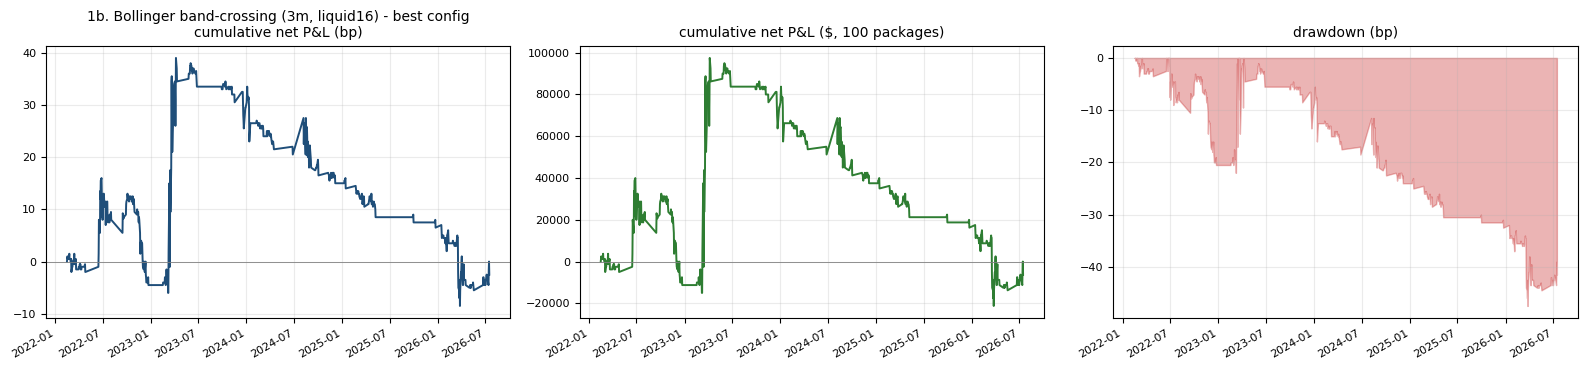


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
U24-Z24-H25    1  2022-02-11 2022-02-14 2022-02-25     8 -2.574      0.00       2.00       2.0      1.5     0.5   1250.0 mean_reversion
Z24-H25-M25    1  2022-02-15 2022-02-16 2022-03-16    19 -2.537     -1.50      -1.50       0.0      1.5    -1.5  -3750.0 mean_reversion
Z23-H24-M24    1  2022-03-01 2022-03-02 2022-03-22    14 -2.781     -2.00      -1.00       1.0      1.5    -0.5  -1250.0 mean_reversion
M25-U25-Z25    1  2022-03-29 2022-03-30 2022-04-26    18 -2.577     -3.00      -2.00       1.0      1.5    -0.5  -1250.0 mean_reversion
Z22-H23-M23   -1  2022-06-13 2022-06-14 2022-06-23     6  2.785     30.50      18.50      12.0      1.5    10.5  26250.0 mean_reversion
U22-Z22-H23   -1  2022-06-13 2022-06-14 2022-07-14    20  2.579     37.00      35.00       2.0      1.5     0.5   1250.0       max_hold
Z24-H25-M25    1  202


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5        59            86.0          -2.5      -0.042     0.305  -0.036      -47.5      13.8          False             False
         belly       1            0.5        59           192.0         162.5       2.754     0.458   0.408     -328.5      13.8           True              True
belly_vs_front       2            1.0        59            70.5          11.5       0.195     0.407   0.120      -64.0      13.8           True              True
 belly_vs_back       2            1.0        59            15.5         -43.5      -0.737     0.356  -0.565      -81.5      13.8          False             False
  -> SHADOWED - a simpler instrument beats the fly on net bp
1b. Bollinger band-crossing (3m, liquid16) - MEDIAN conf

In [7]:
boll = run_family(
    "1b. Bollinger band-crossing (3m, liquid16)", lab=lab,
    signal_fn=lambda L, window, ma_type: bollinger_signal(L, window=window,
                                                          ma_type=ma_type),
    grid_spec={"window": (40, 60, 120), "ma_type": ("sma", "ema"),
               "entry_z": (1.5, 2.0, 2.5), "exit_z": (0.0, 0.5),
               "exit_style": ("band",), "direction": ("fade", "momentum")},
    params=["window", "ma_type", "entry_z", "exit_z", "direction"],
    base=BASE, cls="level", note="band crossing; exit at the centre line")

## 6m flies, same window

Wings two quarters from the belly. Levels and dispersion are roughly 2.5x the
3m fly, so the same 1.5bp round trip is a smaller fraction of the move.


### GRID  (32 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/384 configs


  50/384 configs


  75/384 configs


  100/384 configs


...

  300/384 configs


  325/384 configs


  350/384 configs


  375/384 configs


  384 configs | median -556.00bp | IQR [-865.56, -347.69] | 0% net-positive | best +26.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  ma  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    120   1      2.5        t20      fade       160     0.350       0.162         26.00        65000.0   0.081    -144.00
    250   1      2.5         z0      fade       146     0.315      -0.195        -28.50       -71250.0  -0.053    -296.75
    250   1      2.5       half      fade       145     0.317      -0.272        -39.50       -98750.0  -0.076    -297.25
    120   1      2.5         z0      fade       165     0.345      -0.244        -40.25      -100625.0  -0.121    -221.25
    250   5      2.5         z0      fade       120     0.317      -0.362        -43.50      -108750.0  -0.132    -162.00
    250   1      2.5        t20      fade       143     0.301      -0.311        -44.50      -111250.0  -0

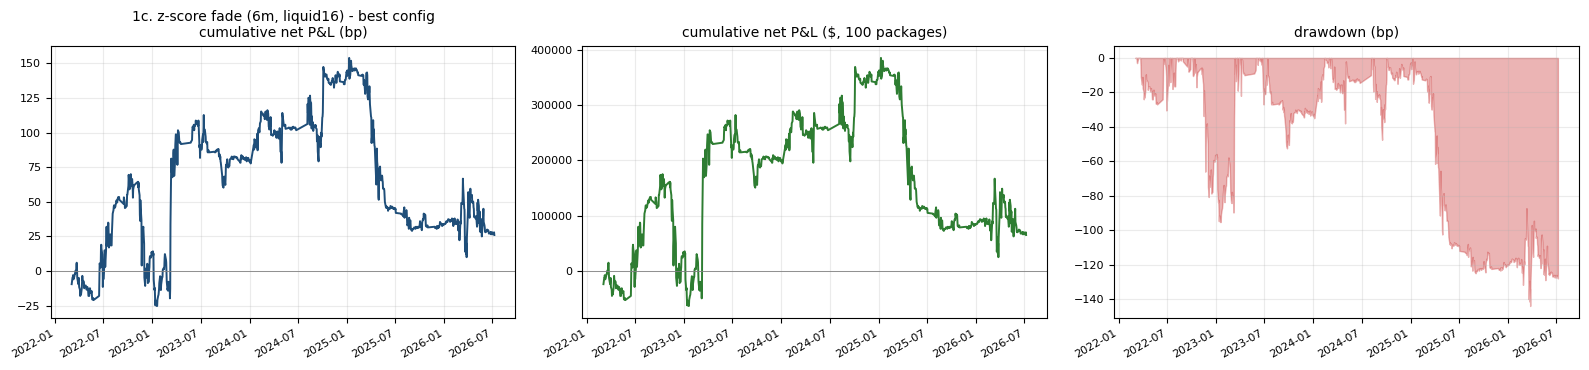


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
Z23-M24-Z24    1  2022-03-02 2022-03-03 2022-03-31    20 -2.593    -13.00      -6.50      6.50      1.5    5.00  12500.0        time
U23-H24-U24    1  2022-03-02 2022-03-03 2022-03-31    20 -2.684     -0.50      -3.50     -3.00      1.5   -4.50 -11250.0        time
Z24-M25-Z25    1  2022-03-04 2022-03-07 2022-04-04    20 -2.562     -5.50      -5.50      0.00      1.5   -1.50  -3750.0        time
H23-U23-H24   -1  2022-03-14 2022-03-15 2022-04-12    20  2.566     34.00      34.50     -0.50      1.5   -2.00  -5000.0        time
M22-Z22-M23   -1  2022-03-21 2022-03-22 2022-04-20    20  2.512     54.50      61.00     -6.50      1.5   -8.00 -20000.0        time
U23-H24-U24    1  2022-04-13 2022-04-14 2022-05-13    20 -2.644    -11.00      -8.50      2.50      1.5    1.00   2500.0        time
M23-Z23-M24    1  2022-04-26 2022-04-27 20


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5       160           266.0          26.0       0.163     0.350   0.081     -144.0      19.8          False             False
         belly       1            0.5       160           775.0         695.0       4.344     0.544   0.667     -267.5      19.8           True              True
belly_vs_front       2            1.0       160           -18.0        -178.0      -1.113     0.369  -0.504     -240.5      19.8          False             False
 belly_vs_back       2            1.0       160           284.0         124.0       0.775     0.450   0.526     -104.5      19.8           True              True
  -> SHADOWED - a simpler instrument beats the fly on net bp
1c. z-score fade (6m, liquid16) - MEDIAN config (the ant

In [8]:
lab6 = load_lab("6m", CONFIG["primary_window"])
out6 = run_family("1c. z-score fade (6m, liquid16)", lab=lab6, signal_fn=SIG,
                  grid_spec=GRID, params=PARAMS, base=BASE, cls="level",
                  note="6m fly: slots (i, i+2, i+4), wings equidistant")

## The long window — 2019+, front 8 slots only

This is the sample-composition test. It buys ZIRP and the hiking cycle at the
price of restricting the cross-section to slots 1–8, which is where the
liquidity actually was before 2022.

42 flies, 1907 sessions, 2019-01-02 -> 2026-07-29

### GRID  (42 keys, 1907 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/384 configs


  50/384 configs


  75/384 configs


  100/384 configs


...

  300/384 configs


  325/384 configs


  350/384 configs


  375/384 configs


  384 configs | median -453.50bp | IQR [-668.75, -303.00] | 0% net-positive | best -121.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  ma  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250   5      2.5        t20      fade       107     0.280      -1.131       -121.00      -302500.0  -0.688    -145.25
    250   5      2.5         z0      fade       107     0.290      -1.187       -127.00      -317500.0  -0.721    -145.25
    250   5      2.5       half      fade       107     0.299      -1.206       -129.00      -322500.0  -0.741    -145.25
    120   3      2.5        t20      fade       129     0.264      -1.002       -129.25      -323125.0  -0.849    -137.50
    120   3      2.5       half      fade       132     0.303      -1.021       -134.75      -336875.0  -0.916    -148.25
    120   1      2.5        t20      fade       145     0.241      -0.981       -142.25      -355625.0  -

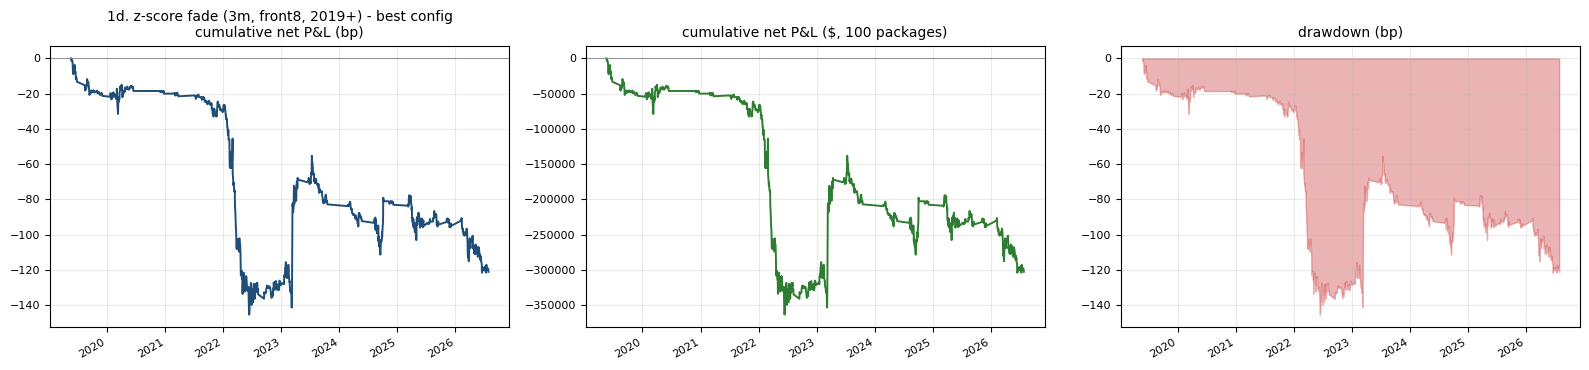


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
U19-Z19-H20    1  2019-05-16 2019-05-17 2019-06-17    20 -2.528     -2.00       -5.0     -3.00      1.5   -4.50 -11250.0        time
H20-M20-U20    1  2019-05-17 2019-05-20 2019-06-18    20 -2.548     -3.50       -2.5      1.00      1.5   -0.50  -1250.0        time
Z19-H20-M20    1  2019-05-24 2019-05-28 2019-06-25    20 -2.650     -3.50       -7.0     -3.50      1.5   -5.00 -12500.0        time
M20-U20-Z20    1  2019-05-28 2019-05-29 2019-06-26    20 -2.790     -4.50       -3.0      1.50      1.5   -0.00     -0.0        time
M19-U19-Z19    1  2019-06-04 2019-06-05 2019-06-18     9 -3.230     -8.25      -10.0     -1.75      1.5   -3.25  -8125.0        time
U19-Z19-H20    1  2019-08-12 2019-08-13 2019-09-11    20 -2.506     -9.00      -10.5     -1.50      1.5   -3.00  -7500.0        time
U20-Z20-H21   -1  2019-08-13 2019-08-14 20

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       107    18.776     0.290      -1.187        -127.0  -0.721
half       107    18.346     0.299      -1.206        -129.0  -0.741
band       107    18.346     0.299      -1.206        -129.0  -0.741
  t5       230     4.974     0.235      -1.115        -256.5  -2.665
 t10       159     9.742     0.283      -1.528        -243.0  -1.560
 t20       107    19.121     0.280      -1.131        -121.0  -0.688

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 107          39.5       0.369     0.449        98750.0
           0.5 107         -14.0      -0.131     0.393       -35000.0
           1.0 107         -67.5      -0.631     0.299      -168750.0
           1.5 107        -121.0      -1.131     0.280      -302500.0
           2.5 107        -228.0      -2.131     0.206      -570000.0
           4.0 107        -388.5      -3.63

1d. z-score fade (3m, front8, 2019+) - MEDIAN config (the anti-selection control)  |  momentum|z1.5|half|hold20|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades   364   skipped    0   hit 23%   avg -1.247bp   avg hold 13.8d
  total    -453.75bp   $   -1,134,375   gross +92.25bp
  daily-MTM Sharpe -1.70   maxDD -453.75bp ($-1,134,375)   worst trade -21.00bp
  t(trade) -5.77   NW t(daily) -4.48   non-overlap SR -0.36   DSR p=0.000 over 384 trials

  LEAGUE ROW  1d. z-score fade (3m, front8, 2019+) / best-config: MARGINAL-maker-only  (taker -228.00bp, maker +39.50bp, DSR p=0.000)

  LEAGUE ROW  1d. z-score fade (3m, front8, 2019+) / median-config: MARGINAL-maker-only  (taker -817.75bp, maker +92.25bp, DSR p=0.000)


In [9]:
lab8 = load_lab(CONFIG["primary_structure"], CONFIG["long_window"])
print(f"{lab8['levels'].shape[1]} flies, {lab8['levels'].shape[0]} sessions, "
      f"{lab8['levels'].index.min().date()} -> {lab8['levels'].index.max().date()}")
out8 = run_family("1d. z-score fade (3m, front8, 2019+)", lab=lab8, signal_fn=SIG,
                  grid_spec=GRID, params=PARAMS, base=BASE, cls="level",
                  note="long history, slots 1-8; the regime-composition test")

## Per-slot breakdown of the primary config

Pooling the strip hides the thing that matters: the front flies move enough to
pay the spread and the back ones do not.

In [10]:
res = out["result"]
per = per_slot_table(res, lab)
if not per.empty:
    print(per.round(3).to_string(index=False))

 slot           cm  n   hit  avg_net_bp  total_net_bp  total_gross_bp  avg_hold  total_net_usd
  2.0       SFR123 16 0.375       1.562          25.0            49.0      15.5        62500.0
  3.0       SFR234 11 0.364      -0.136          -1.5            15.0      20.0        -3750.0
  4.0       SFR345 11 0.545       0.364           4.0            20.5      20.0        10000.0
  5.0       SFR456 11 0.273      -0.045          -0.5            16.0      20.0        -1250.0
  6.0       SFR567  7 0.286      -0.857          -6.0             4.5      20.0       -15000.0
  7.0       SFR678  8 0.125      -2.500         -20.0            -8.0      20.0       -50000.0
  8.0       SFR789 18 0.111      -2.083         -37.5           -10.5      20.0       -93750.0
  9.0   SFR-8-9-10 16 0.125      -1.000         -16.0             8.0      20.0       -40000.0
 10.0  SFR-9-10-11 10 0.000      -1.350         -13.5             1.5      20.0       -33750.0
 11.0 SFR-10-11-12  9 0.111      -0.833          -

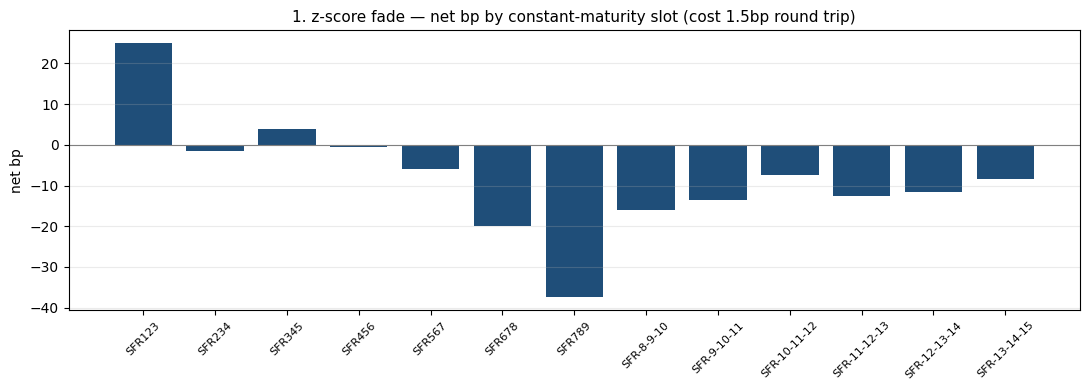

In [11]:
if not res.trades.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(per["cm"], per["total_net_bp"], color="#1f4e79")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_title("1. z-score fade — net bp by constant-maturity slot "
                 f"(cost {CONFIG['cost_bp']}bp round trip)", fontsize=11)
    ax.set_ylabel("net bp")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(alpha=0.25, axis="y")
    fig.tight_layout()
    plt.show()

## Verdict

Read the league rows written above, not this cell: the grid median and the
deflated Sharpe decide, and the linear-shadow block says whether the fly added
anything over the belly outright and the two belly-versus-wing spreads.